In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost as xgb

# loading raw data
trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

# merge
df = trans.merge(identity, on='TransactionID', how='left')

# missing values
missing = (df.isnull().sum() / len(df) * 100)
cols_to_drop = missing[missing > 90].index.tolist()
df = df.drop(columns=cols_to_drop)
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')
df = df.copy()

# all features
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['is_late_night'] = df['hour'].apply(lambda x: 1 if 1 <= x <= 9 else 0)
df['log_amount'] = np.log1p(df['TransactionAmt'])
df['is_card_probe'] = (df['TransactionAmt'] < 1).astype(int)
df['is_threshold_avoid'] = ((df['TransactionAmt'] >= 500) & (df['TransactionAmt'] < 1000)).astype(int)
df['has_identity'] = df['DeviceType'].apply(lambda x: 0 if x == 'Unknown' else 1)
df['is_mobile'] = df['DeviceType'].apply(lambda x: 1 if x == 'mobile' else 0)

card_counts = df.groupby('card1')['TransactionAmt'].count().reset_index()
card_counts.columns = ['card1', 'card1_count']
df = df.merge(card_counts, on='card1', how='left')

card_mean = df.groupby('card1')['TransactionAmt'].mean().reset_index()
card_mean.columns = ['card1', 'card1_mean_amt']
df = df.merge(card_mean, on='card1', how='left')

df['amt_deviation'] = abs(df['TransactionAmt'] - df['card1_mean_amt'])
df['amt_deviation_ratio'] = df['amt_deviation'] / (df['card1_mean_amt'] + 1)

free_emails = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com', 'mail.com']
df['is_free_email'] = df['P_emaildomain'].apply(lambda x: 1 if x in free_emails else 0)
df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

def fraud_rate_encode(df, col):
    fraud_rates = df.groupby(col)['isFraud'].mean()
    return df[col].map(fraud_rates)

df['product_fraud_rate'] = fraud_rate_encode(df, 'ProductCD')
df['card4_fraud_rate'] = fraud_rate_encode(df, 'card4')
df['card6_fraud_rate'] = fraud_rate_encode(df, 'card6')

# drop string columns
drop_cols = ['TransactionID', 'isFraud', 'TransactionDT',
             'ProductCD', 'card4', 'card6',
             'P_emaildomain', 'R_emaildomain', 'DeviceType']
drop_cols = [c for c in drop_cols if c in df.columns]

string_cols = df.drop(columns=drop_cols).select_dtypes(include=['object']).columns.tolist()

X = df.drop(columns=drop_cols + string_cols)
y = df['isFraud']

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Ready!")
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print(f"Fraud rate: {y.mean()*100:.2f}%")

Ready!
Training set: (472432, 407)
Test set: (118108, 407)
Fraud rate: 3.50%


In [2]:
# scale_pos_weight handles class imbalance directly inside XGBoost
# it tells the model: missing a fraud case is 27x more costly than a false alarm
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.1f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr'
)

print("Training XGBoost...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print("Training complete!")

scale_pos_weight: 27.6
Training XGBoost...
[0]	validation_0-aucpr:0.32946
[50]	validation_0-aucpr:0.55922
[100]	validation_0-aucpr:0.61229
[150]	validation_0-aucpr:0.64637
[200]	validation_0-aucpr:0.66882
[250]	validation_0-aucpr:0.68458
[299]	validation_0-aucpr:0.70252
Training complete!


In [3]:
from sklearn.metrics import (precision_score, recall_score, 
                              f1_score, average_precision_score,
                              confusion_matrix, classification_report)

# get predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# core metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_pr = average_precision_score(y_test, y_pred_proba)

print("Model Performance on Test Set")
print("="*40)
print(f"AUC-PR:    {auc_pr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print()
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [18:27:17] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Model Performance on Test Set
AUC-PR:    0.7025
Precision: 0.2982
Recall:    0.8275
F1 Score:  0.4384

Confusion Matrix:
[[105927   8048]
 [   713   3420]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.93      0.96    113975
       Fraud       0.30      0.83      0.44      4133

    accuracy                           0.93    118108
   macro avg       0.65      0.88      0.70    118108
weighted avg       0.97      0.93      0.94    118108



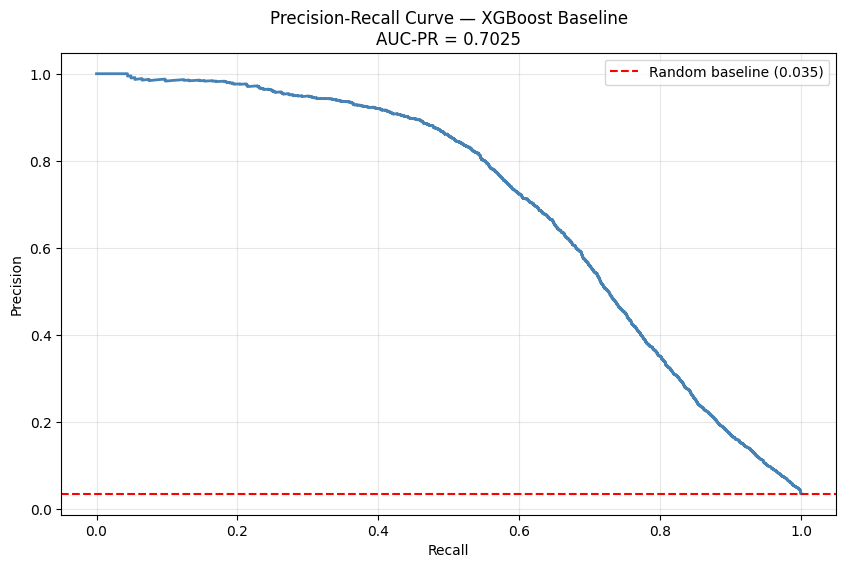

Saved!


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# precision recall curve
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='steelblue', linewidth=2)
plt.axhline(y=0.035, color='red', linestyle='--', label='Random baseline (0.035)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost Baseline\nAUC-PR = 0.7025')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

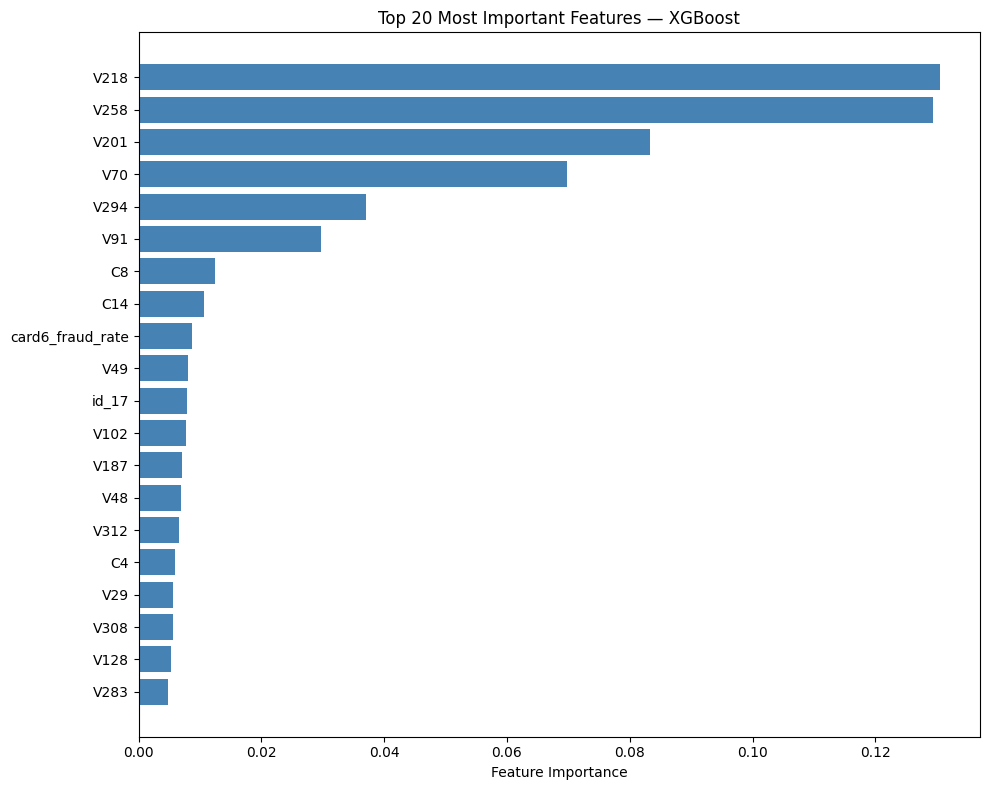

Top 10 features:
         feature  importance
            V218    0.130531
            V258    0.129392
            V201    0.083309
             V70    0.069756
            V294    0.037112
             V91    0.029706
              C8    0.012436
             C14    0.010675
card6_fraud_rate    0.008708
             V49    0.008070


In [5]:
# feature importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][::-1], importance['importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features — XGBoost')
plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(importance.head(10).to_string(index=False))

In [6]:
import pickle

# save model
with open('/kaggle/working/xgb_baseline.pkl', 'wb') as f:
    pickle.dump(model, f)

# save results summary
results = {
    'auc_pr': 0.7025,
    'precision': 0.2982,
    'recall': 0.8275,
    'f1': 0.4384
}

print("Model saved!")
print("\nDay 3 Summary:")
print(f"  AUC-PR:    {results['auc_pr']}")
print(f"  Precision: {results['precision']}")
print(f"  Recall:    {results['recall']}")
print(f"  F1:        {results['f1']}")
print("\nNext: tune the model to improve precision without killing recall")

Model saved!

Day 3 Summary:
  AUC-PR:    0.7025
  Precision: 0.2982
  Recall:    0.8275
  F1:        0.4384

Next: tune the model to improve precision without killing recall


Day 3 — Baseline XGBoost Model

We trained our first XGBoost model on 472k transactions with 407 features.
Class imbalance was handled using scale_pos_weight=27.6 which tells the
model that missing a fraud case is 27x more costly than a false alarm.

Results on 118k unseen test transactions:

AUC-PR: 0.7025 (random baseline would be 0.035)
Recall: 82.75% — caught 3,420 out of 4,133 real fraud cases
Precision: 29.82% — of everything flagged as fraud, 30% was actually fraud
F1: 0.4384

The model works. It genuinely learned fraud patterns from the features
we engineered in Day 2. card6_fraud_rate made the top 10 most important
features out of 407 total which validates the feature engineering approach.

The precision is low — too many false alarms. That's the main problem
to fix in Day 4 through hyperparameter tuning and threshold optimisation.